# Model-Based Reinforcement Learning
## Dyna-Q, Neural Dynamics Models, and Planning with Learned Models

This notebook provides a self-contained, from-scratch implementation of **Model-Based Reinforcement Learning** methods.
We build a tabular world model (Dyna-Q), a neural network dynamics model, and planning algorithms that exploit
learned models for dramatically improved sample efficiency.

**What You'll Learn:**
1. Model-based vs model-free RL: sample efficiency tradeoffs
2. Dyna-Q: integrating learning and planning with a tabular model
3. Neural network dynamics models for continuous environments
4. Planning with learned models: random shooting
5. MBPO-style short-horizon model rollouts
6. Sample efficiency comparison: model-based vs model-free

**Prerequisites:** Q-Learning (Notebook 3), DQN (Notebook 6), basic neural networks.

**References:**
- Sutton, R., *Dyna, an Integrated Architecture for Learning, Planning, and Reacting*, SIGART Bulletin, 1991.
- Nagabandi et al., *Neural Network Dynamics for Model-Based Deep RL with Model-Free Fine-Tuning*, ICRA 2018.
- Janner et al., *When to Trust Your Model: Model-Based Policy Optimization (MBPO)*, NeurIPS 2019.
- Chua et al., *Deep Reinforcement Learning in a Handful of Trials using Probabilistic Ensemble Trajectory Sampling (PETS)*, NeurIPS 2018.

---
## 1. Model-Based RL Framework

In **model-free** RL, the agent learns a policy or value function directly from experience.
In **model-based** RL, the agent also learns a **world model** and uses it for **planning**.

A world model consists of:
- **Dynamics model:** $\hat{f}(s_{t+1} \mid s_t, a_t)$ -- predicts the next state
- **Reward model:** $\hat{r}(s_t, a_t)$ -- predicts the immediate reward

### Direct vs Indirect Use of Models

| Approach | Description | Example |
|---|---|---|
| **Direct (planning)** | Use model to search for good actions at decision time | Random shooting, MPC, MCTS |
| **Indirect (learning)** | Use model to generate synthetic data for training a policy/value function | Dyna-Q, MBPO |

### Why Model-Based?

The key advantage is **sample efficiency**: by learning a model, the agent can generate
unlimited simulated experience and learn from it. The tradeoff is that model errors can
compound during long rollouts, leading to poor policies if the model is inaccurate.

---
## 2. Dyna Architecture

Sutton's **Dyna** architecture unifies direct RL (learning from real experience) with
planning (learning from simulated experience). The key idea:

$$\boxed{\text{Real experience} \xrightarrow{\text{(1) update Q}} Q(s,a) \quad + \quad \text{Model} \xrightarrow{\text{(2) simulated experience}} \xrightarrow{\text{(3) update Q}} Q(s,a)}$$

**Dyna-Q Algorithm (per real step):**
1. Take action $a$ in state $s$, observe $r, s'$
2. **Direct RL:** $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'} Q(s', a') - Q(s,a)]$
3. **Model update:** $\text{Model}(s,a) \leftarrow (r, s')$
4. **Planning:** Repeat $n$ times:
   - Sample a previously visited $(s_m, a_m)$ from the model
   - $(r_m, s'_m) \leftarrow \text{Model}(s_m, a_m)$
   - $Q(s_m, a_m) \leftarrow Q(s_m, a_m) + \alpha[r_m + \gamma \max_{a'} Q(s'_m, a') - Q(s_m, a_m)]$

More planning steps ($n$) = faster learning (more sample efficient), but more computation per real step.

---
## 3. Neural Network Dynamics Models

For continuous state spaces, tabular models are infeasible. Instead, we learn a **neural network**
dynamics model from data.

### Residual Formulation

Rather than predicting $s_{t+1}$ directly, we predict the **change** in state:

$$\hat{s}_{t+1} = s_t + f_\phi(s_t, a_t)$$

This residual formulation is easier to learn because dynamics are often smooth and the
changes between consecutive states are small.

### Training Loss

$$\boxed{L(\phi) = \mathbb{E}\left[\|s_{t+1} - f_\phi(s_t, a_t)\|^2\right]}$$

where $f_\phi$ is trained via supervised learning on collected transitions $(s_t, a_t, s_{t+1})$.

### Planning with Learned Models

Once we have a dynamics model and reward model, we can plan:

- **Random shooting:** Sample $N$ random action sequences, roll them out with the model,
  pick the sequence with the highest cumulative reward.
- **MPC (Model Predictive Control):** At each step, use random shooting to select the first
  action, execute it, observe the real next state, and replan.
- **MBPO:** Use the model for short synthetic rollouts to augment the replay buffer for
  model-free training (e.g., SAC). Short horizons limit model error compounding.

---
## 4. Setup and Constants

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import warnings
warnings.filterwarnings('ignore')

# ---------- reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------- plotting ----------
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})
COLORS = ['steelblue', 'coral', 'seagreen', 'goldenrod', 'mediumpurple']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [2]:
# ==================== Hyperparameters ====================
GAMMA             = 0.99     # discount factor
ALPHA             = 0.1      # Q-learning step size (tabular)
EPSILON           = 0.1      # exploration rate (tabular)
N_PLANNING_STEPS  = 5        # default Dyna planning steps
MODEL_LR          = 1e-3     # neural network model learning rate
N_EPISODES_DYNA   = 100      # episodes for Dyna-Q experiments
N_EPISODES_NN     = 200      # episodes for neural model experiments
HIDDEN_DIM        = 128      # hidden layer size for neural nets
SHOOTING_HORIZON  = 10       # planning horizon for random shooting
N_CANDIDATES      = 500      # number of candidate action sequences

print("Hyperparameters set.")

Hyperparameters set.


---
## 5. SimpleGridWorld Environment

We build a 6x9 grid maze (inspired by Sutton & Barto, Example 8.1) with walls
blocking the direct path from start to goal.

In [3]:
class SimpleGridWorld:
    """
    6x9 grid world with walls (Sutton & Barto Dyna maze).
    
    Layout (6 rows x 9 cols):
      - Start: (2, 0)
      - Goal:  (0, 8)
      - Walls block the direct path
    
    Actions: 0=up, 1=down, 2=left, 3=right
    Reward: -1 per step, 0 at goal (terminal)
    """

    def __init__(self):
        self.rows = 6
        self.cols = 9
        self.start = (2, 0)
        self.goal = (0, 8)
        self.n_states = self.rows * self.cols
        self.n_actions = 4

        # walls: set of (row, col) positions that are impassable
        self.walls = {
            (1, 2), (2, 2), (3, 2),  # vertical wall
            (4, 5),                   # single block
            (0, 7), (1, 7), (2, 7),   # vertical wall near goal
        }

        # action deltas: up, down, left, right
        self.action_deltas = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        self.action_names = ['up', 'down', 'left', 'right']
        self.state = self.start

    def state_to_idx(self, state):
        """Convert (row, col) to integer index."""
        return state[0] * self.cols + state[1]

    def idx_to_state(self, idx):
        """Convert integer index to (row, col)."""
        return (idx // self.cols, idx % self.cols)

    def reset(self):
        """Reset to start position. Returns state index."""
        self.state = self.start
        return self.state_to_idx(self.state)

    def step(self, action):
        """Take an action. Returns (next_state_idx, reward, done)."""
        dr, dc = self.action_deltas[action]
        new_r = self.state[0] + dr
        new_c = self.state[1] + dc

        # boundary check and wall check
        if (0 <= new_r < self.rows and 0 <= new_c < self.cols
                and (new_r, new_c) not in self.walls):
            self.state = (new_r, new_c)

        # check if goal reached
        done = (self.state == self.goal)
        reward = 0.0 if done else -1.0
        return self.state_to_idx(self.state), reward, done

    def render_grid(self):
        """Return a string representation of the grid."""
        lines = []
        for r in range(self.rows):
            row_str = ''
            for c in range(self.cols):
                if (r, c) == self.state:
                    row_str += ' A '
                elif (r, c) == self.goal:
                    row_str += ' G '
                elif (r, c) == self.start:
                    row_str += ' S '
                elif (r, c) in self.walls:
                    row_str += ' # '
                else:
                    row_str += ' . '
            lines.append(row_str)
        return '\n'.join(lines)


# Quick test
env_test = SimpleGridWorld()
s = env_test.reset()
print(f"Start state index: {s}, position: {env_test.idx_to_state(s)}")
print(f"Grid size: {env_test.rows}x{env_test.cols}, States: {env_test.n_states}, Actions: {env_test.n_actions}")
print()
print(env_test.render_grid())

Start state index: 18, position: (2, 0)
Grid size: 6x9, States: 54, Actions: 4

 .  .  .  .  .  .  .  #  G 
 .  .  #  .  .  .  .  #  . 
 A  .  #  .  .  .  .  #  . 
 .  .  #  .  .  .  .  .  . 
 .  .  .  .  .  #  .  .  . 
 .  .  .  .  .  .  .  .  . 


---
## 6. Tabular Model for Dyna-Q

In [4]:
class TabularModel:
    """
    Deterministic tabular model that records observed transitions.
    model[s][a] = (reward, next_state)
    """

    def __init__(self):
        # model[s][a] = (r, s')
        self.model = defaultdict(dict)
        # track all (s, a) pairs we have seen
        self.visited_sa = []

    def update(self, s, a, r, s_next):
        """Record a transition."""
        if a not in self.model[s]:
            self.visited_sa.append((s, a))
        self.model[s][a] = (r, s_next)

    def sample(self):
        """Sample a random previously-seen (s, a) pair."""
        idx = np.random.randint(len(self.visited_sa))
        return self.visited_sa[idx]

    def predict(self, s, a):
        """Return stored (reward, next_state) for (s, a)."""
        return self.model[s][a]

    def __len__(self):
        return len(self.visited_sa)


# Sanity check
tm = TabularModel()
tm.update(0, 1, -1.0, 5)
tm.update(5, 2, -1.0, 10)
print(f"Model has {len(tm)} (s,a) pairs")
print(f"Predict (0,1) -> {tm.predict(0, 1)}")
print(f"Random sample: {tm.sample()}")

Model has 2 (s,a) pairs
Predict (0,1) -> (-1.0, 5)
Random sample: (0, 1)


---
## 7. Dyna-Q Algorithm

In [5]:
def dyna_q(env, n_episodes, n_planning, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON, seed=SEED):
    """
    Dyna-Q: Q-learning with n planning steps per real step.
    
    Args:
        env: SimpleGridWorld instance
        n_episodes: number of episodes to train
        n_planning: number of simulated Q-updates per real step
        alpha: learning rate
        gamma: discount factor
        epsilon: exploration rate
        seed: random seed
    
    Returns:
        Q: learned Q-table (dict of dicts)
        episode_steps: list of steps per episode
        cumulative_steps: list of cumulative environment steps
    """
    np.random.seed(seed)

    # Q-table initialised to 0
    Q = defaultdict(lambda: np.zeros(env.n_actions))
    model = TabularModel()

    episode_steps = []
    cumulative_steps = []
    total_steps = 0

    for ep in range(n_episodes):
        s = env.reset()
        done = False
        steps = 0

        while not done:
            # epsilon-greedy action selection
            if np.random.random() < epsilon:
                a = np.random.randint(env.n_actions)
            else:
                a = np.argmax(Q[s])

            # take action in real environment
            s_next, r, done = env.step(a)
            steps += 1
            total_steps += 1

            # (1) Direct RL: Q-learning update from real experience
            td_target = r + gamma * np.max(Q[s_next]) * (1 - done)
            Q[s][a] += alpha * (td_target - Q[s][a])

            # (2) Model update: record transition
            model.update(s, a, r, s_next)

            # (3) Planning: n simulated Q-updates from model
            for _ in range(n_planning):
                s_m, a_m = model.sample()
                r_m, s_next_m = model.predict(s_m, a_m)
                done_m = (s_next_m == env.state_to_idx(env.goal))
                td_target_m = r_m + gamma * np.max(Q[s_next_m]) * (1 - done_m)
                Q[s_m][a_m] += alpha * (td_target_m - Q[s_m][a_m])

            s = s_next

        episode_steps.append(steps)
        cumulative_steps.append(total_steps)

    return Q, episode_steps, cumulative_steps


print("Dyna-Q function defined.")

Dyna-Q function defined.


---
## 8. Dyna-Q Experiments: Varying Planning Steps

In [6]:
# Run Dyna-Q with different numbers of planning steps
planning_configs = [0, 5, 50]
results_dyna = {}

for n_plan in planning_configs:
    env_dyna = SimpleGridWorld()
    Q, ep_steps, cum_steps = dyna_q(
        env_dyna, n_episodes=N_EPISODES_DYNA, n_planning=n_plan, seed=SEED
    )
    results_dyna[n_plan] = {
        'Q': Q,
        'episode_steps': ep_steps,
        'cumulative_steps': cum_steps,
    }
    final_10 = np.mean(ep_steps[-10:])
    print(f"n_planning={n_plan:3d}: avg steps (last 10) = {final_10:.1f}, "
          f"total env steps = {cum_steps[-1]}")

print("\nDyna-Q training complete.")

n_planning=  0: avg steps (last 10) = 41.9, total env steps = 10702
n_planning=  5: avg steps (last 10) = 16.8, total env steps = 3538
n_planning= 50: avg steps (last 10) = 15.9, total env steps = 2153

Dyna-Q training complete.


---
## 9. Visualization: Dyna-Q Learning Curves

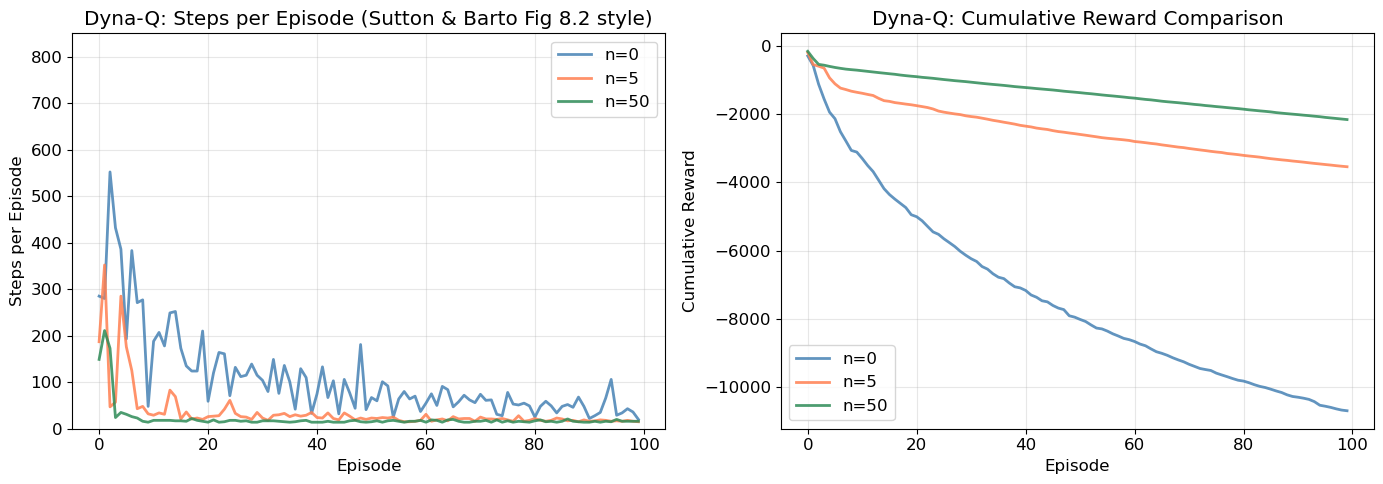

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Steps per episode (like Sutton & Barto Fig 8.2) ---
ax = axes[0]
for i, n_plan in enumerate(planning_configs):
    steps = results_dyna[n_plan]['episode_steps']
    # clip for readability (early episodes can be very long)
    steps_clipped = np.minimum(steps, 800)
    ax.plot(steps_clipped, label=f'n={n_plan}', color=COLORS[i], alpha=0.85)
ax.set_xlabel('Episode')
ax.set_ylabel('Steps per Episode')
ax.set_title('Dyna-Q: Steps per Episode (Sutton & Barto Fig 8.2 style)')
ax.legend()
ax.set_ylim(0, 850)

# --- Cumulative reward (negative of cumulative steps) ---
ax = axes[1]
for i, n_plan in enumerate(planning_configs):
    cum_reward = -np.array(results_dyna[n_plan]['episode_steps']).cumsum()
    ax.plot(cum_reward, label=f'n={n_plan}', color=COLORS[i], alpha=0.85)
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Dyna-Q: Cumulative Reward Comparison')
ax.legend()

plt.tight_layout()
plt.show()

---
## 10. Visualization: Grid World with Learned Policy

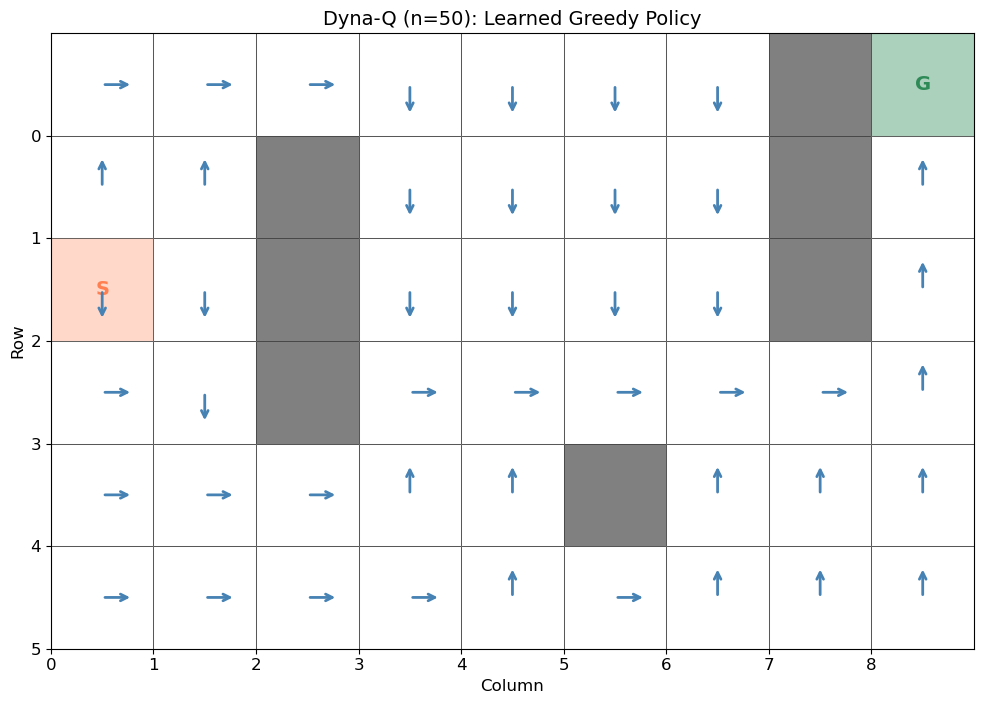

In [8]:
def plot_grid_policy(Q, env, title='Learned Policy'):
    """
    Visualize the learned greedy policy on the grid world using arrows.
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    # draw grid
    for r in range(env.rows):
        for c in range(env.cols):
            if (r, c) in env.walls:
                ax.add_patch(plt.Rectangle((c, env.rows - 1 - r), 1, 1,
                             facecolor='gray', edgecolor='black', linewidth=0.5))
            elif (r, c) == env.goal:
                ax.add_patch(plt.Rectangle((c, env.rows - 1 - r), 1, 1,
                             facecolor='seagreen', alpha=0.4, edgecolor='black', linewidth=0.5))
                ax.text(c + 0.5, env.rows - 1 - r + 0.5, 'G',
                        ha='center', va='center', fontsize=14, fontweight='bold', color='seagreen')
            elif (r, c) == env.start:
                ax.add_patch(plt.Rectangle((c, env.rows - 1 - r), 1, 1,
                             facecolor='coral', alpha=0.3, edgecolor='black', linewidth=0.5))
                ax.text(c + 0.5, env.rows - 1 - r + 0.5, 'S',
                        ha='center', va='center', fontsize=14, fontweight='bold', color='coral')
            else:
                ax.add_patch(plt.Rectangle((c, env.rows - 1 - r), 1, 1,
                             facecolor='white', edgecolor='black', linewidth=0.5))

    # draw policy arrows
    # action deltas for arrows: up, down, left, right
    arrow_dx = [0, 0, -0.3, 0.3]
    arrow_dy = [0.3, -0.3, 0, 0]

    for r in range(env.rows):
        for c in range(env.cols):
            if (r, c) in env.walls or (r, c) == env.goal:
                continue
            s_idx = env.state_to_idx((r, c))
            if s_idx in Q and np.any(Q[s_idx] != 0):
                best_a = np.argmax(Q[s_idx])
                cx = c + 0.5
                cy = env.rows - 1 - r + 0.5
                ax.annotate('', xy=(cx + arrow_dx[best_a], cy + arrow_dy[best_a]),
                            xytext=(cx, cy),
                            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))

    ax.set_xlim(0, env.cols)
    ax.set_ylim(0, env.rows)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14)
    ax.set_xticks(range(env.cols))
    ax.set_yticks(range(env.rows))
    ax.set_xticklabels(range(env.cols))
    ax.set_yticklabels(range(env.rows - 1, -1, -1))
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    plt.tight_layout()
    plt.show()


# Plot the policy learned by Dyna-Q(n=50)
Q_best = results_dyna[50]['Q']
env_vis = SimpleGridWorld()
plot_grid_policy(Q_best, env_vis, title='Dyna-Q (n=50): Learned Greedy Policy')

---
## 11. Neural Network Dynamics Model

We now move to continuous state spaces (CartPole-v1) and learn a dynamics model
with a neural network using the residual formulation.

In [9]:
class DynamicsModel(nn.Module):
    """
    Neural network dynamics model with residual formulation.
    
    Predicts the CHANGE in state: delta_s = f_phi(s, a)
    Next state prediction: s' = s + delta_s
    
    Input: state (state_dim) concatenated with one-hot action (action_dim)
    Output: delta_state (state_dim)
    """

    def __init__(self, state_dim, action_dim, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.state_dim = state_dim
        self.action_dim = action_dim

        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim),
        )

    def forward(self, state, action_onehot):
        """Predict delta_state given state and one-hot action."""
        x = torch.cat([state, action_onehot], dim=-1)
        delta = self.net(x)
        return delta

    def predict(self, state, action_onehot):
        """Predict next state using residual formulation: s' = s + delta."""
        delta = self.forward(state, action_onehot)
        return state + delta


class RewardModel(nn.Module):
    """
    Neural network reward model.
    Input: state + one-hot action
    Output: predicted scalar reward
    """

    def __init__(self, state_dim, action_dim, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, state, action_onehot):
        x = torch.cat([state, action_onehot], dim=-1)
        return self.net(x).squeeze(-1)


# Verify shapes
_state_dim = 4  # CartPole
_action_dim = 2
_dyn = DynamicsModel(_state_dim, _action_dim)
_rew = RewardModel(_state_dim, _action_dim)
_s = torch.randn(8, _state_dim)
_a = torch.zeros(8, _action_dim)
_a[:, 0] = 1.0
print(f"Dynamics model output shape: {_dyn(_s, _a).shape}")     # (8, 4)
print(f"Dynamics predict shape:      {_dyn.predict(_s, _a).shape}")  # (8, 4)
print(f"Reward model output shape:   {_rew(_s, _a).shape}")     # (8,)
print(f"Dynamics params: {sum(p.numel() for p in _dyn.parameters()):,}")
print(f"Reward params:   {sum(p.numel() for p in _rew.parameters()):,}")

Dynamics model output shape: torch.Size([8, 4])
Dynamics predict shape:      torch.Size([8, 4])
Reward model output shape:   torch.Size([8])
Dynamics params: 17,924
Reward params:   1,025


---
## 12. Data Buffer for Supervised Model Training

In [10]:
class DataBuffer:
    """
    Buffer to store (state, action, next_state, reward) transitions
    for supervised training of the dynamics and reward models.
    """

    def __init__(self):
        self.states = []
        self.actions = []
        self.next_states = []
        self.rewards = []

    def add(self, s, a, s_next, r):
        """Add a single transition."""
        self.states.append(s)
        self.actions.append(a)
        self.next_states.append(s_next)
        self.rewards.append(r)

    def sample(self, batch_size):
        """Sample a random mini-batch."""
        n = len(self.states)
        idxs = np.random.choice(n, size=min(batch_size, n), replace=False)
        return (
            np.array([self.states[i] for i in idxs]),
            np.array([self.actions[i] for i in idxs]),
            np.array([self.next_states[i] for i in idxs]),
            np.array([self.rewards[i] for i in idxs]),
        )

    def all_data(self):
        """Return all stored data."""
        return (
            np.array(self.states),
            np.array(self.actions),
            np.array(self.next_states),
            np.array(self.rewards),
        )

    def __len__(self):
        return len(self.states)


print("DataBuffer defined.")

DataBuffer defined.


---
## 13. Collect Random Data and Train Models

In [11]:
def collect_random_data(env_name='CartPole-v1', n_episodes=50, seed=SEED):
    """
    Collect transition data using a random policy.
    Returns a filled DataBuffer.
    """
    env = gym.make(env_name)
    buffer = DataBuffer()
    np.random.seed(seed)

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        while not done:
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.add(state.copy(), action, next_state.copy(), reward)
            state = next_state

    env.close()
    return buffer


def action_to_onehot(actions, n_actions):
    """Convert integer actions to one-hot vectors."""
    if isinstance(actions, (int, np.integer)):
        oh = np.zeros(n_actions)
        oh[actions] = 1.0
        return oh
    onehot = np.zeros((len(actions), n_actions))
    for i, a in enumerate(actions):
        onehot[i, a] = 1.0
    return onehot


def train_dynamics_model(dyn_model, rew_model, buffer, n_epochs=50, batch_size=256, lr=MODEL_LR):
    """
    Train dynamics and reward models via supervised learning on buffer data.
    Returns lists of dynamics and reward losses per epoch.
    """
    dyn_optimizer = optim.Adam(dyn_model.parameters(), lr=lr)
    rew_optimizer = optim.Adam(rew_model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()

    states, actions, next_states, rewards = buffer.all_data()
    n_actions = dyn_model.action_dim

    # convert to tensors
    states_t = torch.FloatTensor(states).to(device)
    actions_oh = torch.FloatTensor(action_to_onehot(actions, n_actions)).to(device)
    next_states_t = torch.FloatTensor(next_states).to(device)
    rewards_t = torch.FloatTensor(rewards).to(device)

    # target for dynamics: delta = s' - s
    deltas_t = next_states_t - states_t

    n = len(states)
    dyn_losses = []
    rew_losses = []

    for epoch in range(n_epochs):
        # shuffle
        perm = torch.randperm(n)
        epoch_dyn_loss = 0.0
        epoch_rew_loss = 0.0
        n_batches = 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            s_b = states_t[idx]
            a_b = actions_oh[idx]
            d_b = deltas_t[idx]
            r_b = rewards_t[idx]

            # dynamics model update
            pred_delta = dyn_model(s_b, a_b)
            dyn_loss = mse_loss(pred_delta, d_b)
            dyn_optimizer.zero_grad()
            dyn_loss.backward()
            dyn_optimizer.step()

            # reward model update
            pred_rew = rew_model(s_b, a_b)
            rew_loss = mse_loss(pred_rew, r_b)
            rew_optimizer.zero_grad()
            rew_loss.backward()
            rew_optimizer.step()

            epoch_dyn_loss += dyn_loss.item()
            epoch_rew_loss += rew_loss.item()
            n_batches += 1

        dyn_losses.append(epoch_dyn_loss / n_batches)
        rew_losses.append(epoch_rew_loss / n_batches)

    return dyn_losses, rew_losses


# Collect data and train
print("Collecting random data from CartPole-v1...")
data_buffer = collect_random_data(n_episodes=100, seed=SEED)
print(f"Collected {len(data_buffer)} transitions.")

# Instantiate models
STATE_DIM = 4   # CartPole state dimension
ACTION_DIM = 2  # CartPole action dimension

dynamics_model = DynamicsModel(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)
reward_model = RewardModel(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)

print("Training dynamics and reward models...")
dyn_losses, rew_losses = train_dynamics_model(
    dynamics_model, reward_model, data_buffer, n_epochs=80, lr=MODEL_LR
)
print(f"Final dynamics loss: {dyn_losses[-1]:.6f}")
print(f"Final reward loss:   {rew_losses[-1]:.6f}")

Collected 2199 transitions.
Training dynamics and reward models...
Final dynamics loss: 0.000001
Final reward loss:   0.000045


---
## 14. Visualization: Model Prediction Error Over Training

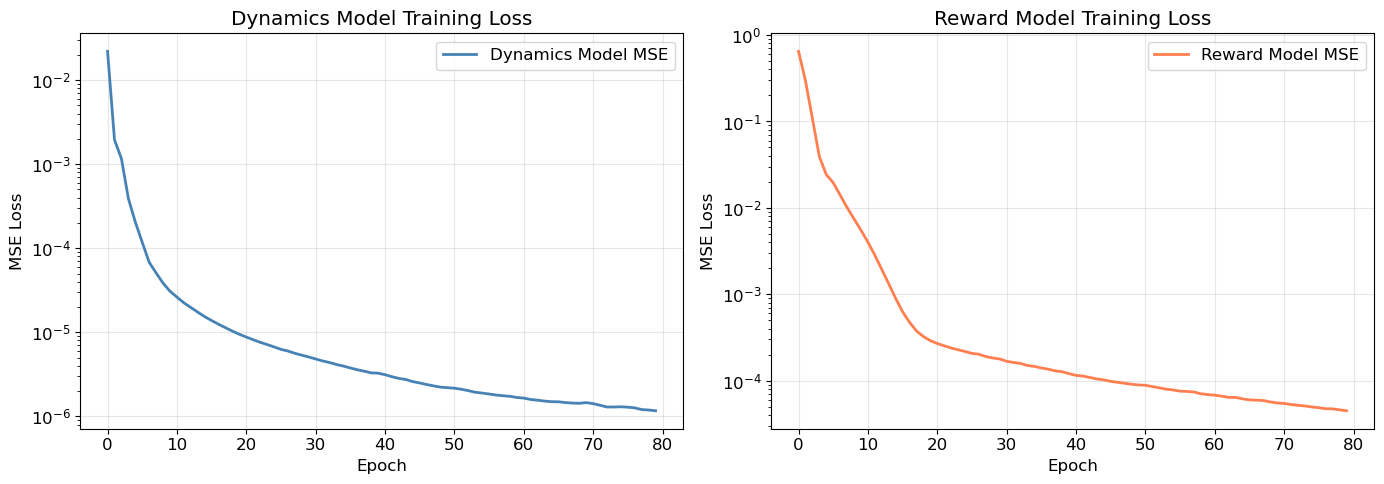

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(dyn_losses, color=COLORS[0], label='Dynamics Model MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Dynamics Model Training Loss')
ax.set_yscale('log')
ax.legend()

ax = axes[1]
ax.plot(rew_losses, color=COLORS[1], label='Reward Model MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Reward Model Training Loss')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

---
## 15. Visualization: Predicted vs Actual Next States

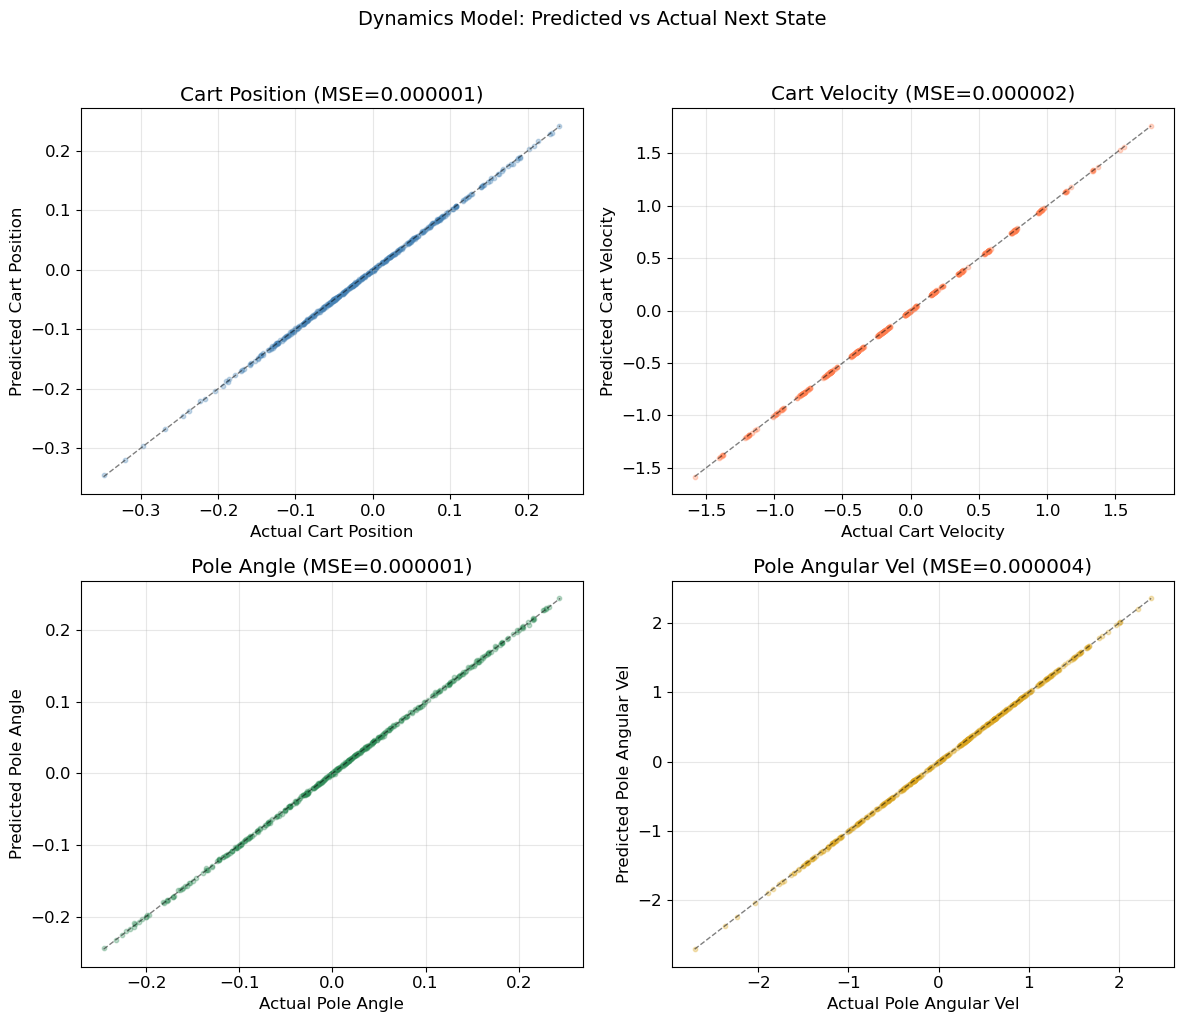

Overall prediction MSE on held-out data: 0.000002


In [13]:
# Evaluate dynamics model on held-out data
eval_buffer = collect_random_data(n_episodes=20, seed=SEED + 1000)
states_eval, actions_eval, next_states_eval, _ = eval_buffer.all_data()

states_t = torch.FloatTensor(states_eval).to(device)
actions_oh = torch.FloatTensor(action_to_onehot(actions_eval, ACTION_DIM)).to(device)

with torch.no_grad():
    predicted_next = dynamics_model.predict(states_t, actions_oh).cpu().numpy()

state_names = ['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Angular Vel']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, state_names)):
    actual = next_states_eval[:, i]
    pred = predicted_next[:, i]

    ax.scatter(actual, pred, alpha=0.3, s=10, color=COLORS[i % len(COLORS)])

    # perfect prediction line
    vmin = min(actual.min(), pred.min())
    vmax = max(actual.max(), pred.max())
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', alpha=0.5, linewidth=1)

    mse_i = np.mean((actual - pred) ** 2)
    ax.set_xlabel(f'Actual {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name} (MSE={mse_i:.6f})')

plt.suptitle('Dynamics Model: Predicted vs Actual Next State', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

overall_mse = np.mean((next_states_eval - predicted_next) ** 2)
print(f"Overall prediction MSE on held-out data: {overall_mse:.6f}")

---
## 16. Random Shooting Planner

In [14]:
def random_shooting(dynamics_model, reward_model, state, n_actions,
                    n_candidates=N_CANDIDATES, horizon=SHOOTING_HORIZON,
                    gamma=GAMMA):
    """
    Random shooting planner: sample random action sequences, rollout
    with the learned model, return the first action of the best sequence.
    
    Args:
        dynamics_model: trained DynamicsModel
        reward_model: trained RewardModel
        state: current state (numpy array)
        n_actions: number of discrete actions
        n_candidates: number of random action sequences to evaluate
        horizon: planning horizon (number of steps to rollout)
        gamma: discount factor
    
    Returns:
        best_action: the first action of the highest-reward sequence
        best_reward: the discounted cumulative reward of the best sequence
    """
    dynamics_model.eval()
    reward_model.eval()

    with torch.no_grad():
        # sample N random action sequences of length H
        action_seqs = np.random.randint(0, n_actions, size=(n_candidates, horizon))

        # initial state replicated for all candidates
        current_states = torch.FloatTensor(
            np.tile(state, (n_candidates, 1))
        ).to(device)  # (N, state_dim)

        cumulative_rewards = torch.zeros(n_candidates).to(device)
        discount = 1.0

        for t in range(horizon):
            actions_t = action_seqs[:, t]  # (N,)
            actions_oh = torch.FloatTensor(
                action_to_onehot(actions_t, n_actions)
            ).to(device)  # (N, n_actions)

            # predict reward
            pred_rewards = reward_model(current_states, actions_oh)  # (N,)
            cumulative_rewards += discount * pred_rewards
            discount *= gamma

            # predict next state
            current_states = dynamics_model.predict(current_states, actions_oh)

    # pick the best sequence
    best_idx = cumulative_rewards.argmax().item()
    best_action = action_seqs[best_idx, 0]
    best_reward = cumulative_rewards[best_idx].item()

    return best_action, best_reward


# Quick test
test_state = np.array([0.0, 0.0, 0.0, 0.0])
action, reward = random_shooting(dynamics_model, reward_model, test_state, ACTION_DIM)
print(f"Random shooting test -> action: {action}, expected reward: {reward:.3f}")

Random shooting test -> action: 0, expected reward: 9.646


---
## 17. MPC Loop: Model-Based Control with Random Shooting

In [15]:
def run_mpc(env_name='CartPole-v1', dynamics_model=None, reward_model=None,
            data_buffer=None, n_episodes=50, retrain_every=10,
            retrain_epochs=20, n_candidates=N_CANDIDATES,
            horizon=SHOOTING_HORIZON, seed=SEED):
    """
    Model Predictive Control loop:
      - At each step, use random shooting to pick best action
      - Execute in real env, add transition to buffer
      - Periodically retrain the model on accumulated data
    
    Returns:
        episode_rewards: list of total rewards per episode
        env_steps: list of cumulative environment steps per episode
    """
    env = gym.make(env_name)
    n_actions = env.action_space.n
    episode_rewards = []
    env_steps = []
    total_env_steps = 0

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        ep_reward = 0.0

        while not done:
            # plan with random shooting
            action, _ = random_shooting(
                dynamics_model, reward_model, state, n_actions,
                n_candidates=n_candidates, horizon=horizon
            )

            # execute in real environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_env_steps += 1

            # add to buffer
            data_buffer.add(state.copy(), action, next_state.copy(), reward)

            state = next_state
            ep_reward += reward

        episode_rewards.append(ep_reward)
        env_steps.append(total_env_steps)

        # periodically retrain model
        if (ep + 1) % retrain_every == 0 and ep > 0:
            train_dynamics_model(
                dynamics_model, reward_model, data_buffer,
                n_epochs=retrain_epochs, lr=MODEL_LR
            )

        if (ep + 1) % 10 == 0:
            avg_last10 = np.mean(episode_rewards[-10:])
            print(f"  MPC Ep {ep+1:3d} | Reward {ep_reward:6.1f} | "
                  f"Avg10 {avg_last10:6.1f} | Env Steps {total_env_steps}")

    env.close()
    return episode_rewards, env_steps


# Run MPC
print("Running MPC with random shooting planner...")
print("(This uses the pre-trained dynamics and reward models)")

# Reset models and retrain from scratch for a clean experiment
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
dynamics_model_mpc = DynamicsModel(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)
reward_model_mpc = RewardModel(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)

# Initial training on random data
mpc_buffer = collect_random_data(n_episodes=50, seed=SEED)
train_dynamics_model(dynamics_model_mpc, reward_model_mpc, mpc_buffer, n_epochs=60, lr=MODEL_LR)

mpc_rewards, mpc_env_steps = run_mpc(
    dynamics_model=dynamics_model_mpc,
    reward_model=reward_model_mpc,
    data_buffer=mpc_buffer,
    n_episodes=50,
    retrain_every=10,
    n_candidates=N_CANDIDATES,
    horizon=SHOOTING_HORIZON,
    seed=SEED,
)
print(f"\nMPC average reward (last 10): {np.mean(mpc_rewards[-10:]):.1f}")

Running MPC with random shooting planner...
(This uses the pre-trained dynamics and reward models)
  MPC Ep  10 | Reward    9.0 | Avg10    9.2 | Env Steps 92
  MPC Ep  20 | Reward    9.0 | Avg10    9.3 | Env Steps 185
  MPC Ep  30 | Reward    9.0 | Avg10    9.7 | Env Steps 282
  MPC Ep  40 | Reward   10.0 | Avg10   10.0 | Env Steps 382
  MPC Ep  50 | Reward   10.0 | Avg10    9.6 | Env Steps 478

MPC average reward (last 10): 9.6


---
## 18. Model-Free Baseline: Q-Learning on CartPole

In [16]:
class SimpleQNetwork(nn.Module):
    """Simple Q-network for CartPole."""

    def __init__(self, state_dim, action_dim, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)


def train_model_free_dqn(env_name='CartPole-v1', n_episodes=200, seed=SEED):
    """
    Train a simple DQN (model-free baseline) to compare sample efficiency.
    Returns episode rewards and cumulative environment steps.
    """
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    env = gym.make(env_name)

    q_net = SimpleQNetwork(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)
    target_net = SimpleQNetwork(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.Adam(q_net.parameters(), lr=1e-3)

    # simple replay buffer
    replay = []
    REPLAY_CAP = 10_000
    BATCH = 64
    eps = 1.0

    episode_rewards = []
    env_steps_list = []
    total_env_steps = 0

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        ep_reward = 0.0

        while not done:
            # epsilon-greedy
            if random.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    s_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                    action = q_net(s_t).argmax(dim=1).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_env_steps += 1

            replay.append((state, action, reward, next_state, float(done)))
            if len(replay) > REPLAY_CAP:
                replay.pop(0)

            # train if enough data
            if len(replay) >= BATCH:
                batch = random.sample(replay, BATCH)
                s_b = torch.FloatTensor(np.array([t[0] for t in batch])).to(device)
                a_b = torch.LongTensor([t[1] for t in batch]).unsqueeze(1).to(device)
                r_b = torch.FloatTensor([t[2] for t in batch]).unsqueeze(1).to(device)
                ns_b = torch.FloatTensor(np.array([t[3] for t in batch])).to(device)
                d_b = torch.FloatTensor([t[4] for t in batch]).unsqueeze(1).to(device)

                q_vals = q_net(s_b).gather(1, a_b)
                with torch.no_grad():
                    next_q = target_net(ns_b).max(dim=1, keepdim=True)[0]
                    targets = r_b + GAMMA * next_q * (1 - d_b)

                loss = nn.MSELoss()(q_vals, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            state = next_state
            ep_reward += reward

        # target network update and epsilon decay
        if (ep + 1) % 10 == 0:
            target_net.load_state_dict(q_net.state_dict())
        eps = max(0.01, eps * 0.995)

        episode_rewards.append(ep_reward)
        env_steps_list.append(total_env_steps)

        if (ep + 1) % 50 == 0:
            avg = np.mean(episode_rewards[-50:])
            print(f"  DQN Ep {ep+1:3d} | Reward {ep_reward:6.1f} | "
                  f"Avg50 {avg:6.1f} | Env Steps {total_env_steps}")

    env.close()
    return episode_rewards, env_steps_list


print("Training model-free DQN baseline...")
mf_rewards, mf_env_steps = train_model_free_dqn(n_episodes=N_EPISODES_NN, seed=SEED)
print(f"\nModel-free DQN avg reward (last 50): {np.mean(mf_rewards[-50:]):.1f}")

Training model-free DQN baseline...
  DQN Ep  50 | Reward   21.0 | Avg50   26.2 | Env Steps 1308
  DQN Ep 100 | Reward  139.0 | Avg50   42.5 | Env Steps 3432
  DQN Ep 150 | Reward   67.0 | Avg50   65.7 | Env Steps 6715
  DQN Ep 200 | Reward   45.0 | Avg50   65.2 | Env Steps 9974

Model-free DQN avg reward (last 50): 65.2


---
## 19. Visualization: Random Shooting vs Random Policy

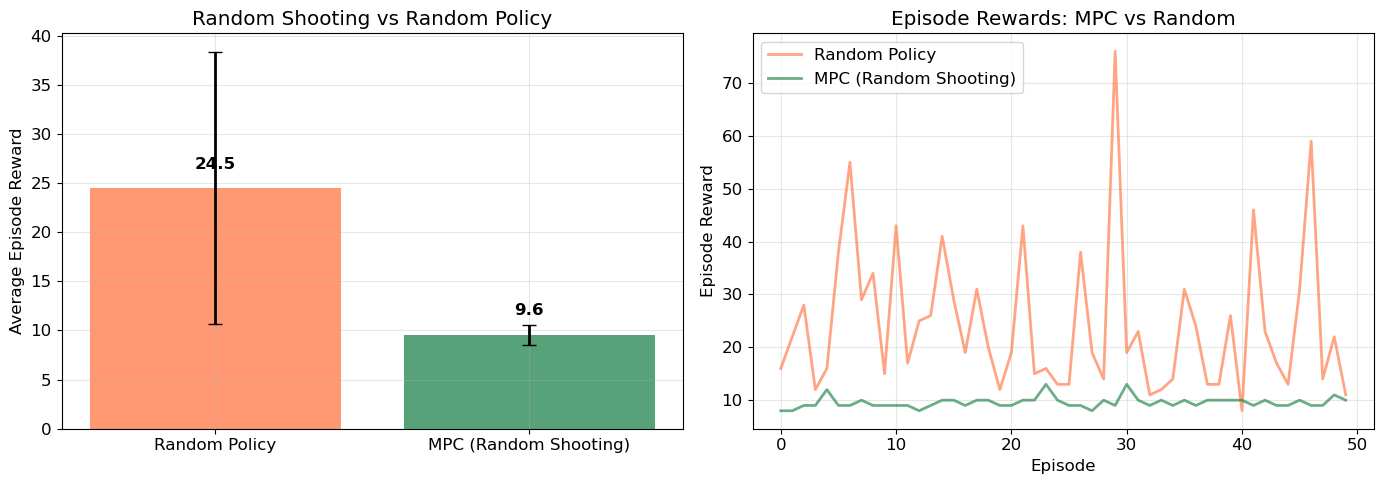

Random policy: 24.5 +/- 13.9
MPC planning:  9.6 +/- 1.0


In [17]:
def evaluate_random_policy(env_name='CartPole-v1', n_episodes=50, seed=SEED):
    """Evaluate a purely random policy."""
    env = gym.make(env_name)
    rewards = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep + 5000)
        done = False
        ep_reward = 0.0
        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
        rewards.append(ep_reward)
    env.close()
    return rewards


random_policy_rewards = evaluate_random_policy(n_episodes=50, seed=SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar comparison
ax = axes[0]
means = [np.mean(random_policy_rewards), np.mean(mpc_rewards)]
stds = [np.std(random_policy_rewards), np.std(mpc_rewards)]
labels = ['Random Policy', 'MPC (Random Shooting)']
bars = ax.bar(labels, means, yerr=stds, color=[COLORS[1], COLORS[2]], alpha=0.8, capsize=5)
ax.set_ylabel('Average Episode Reward')
ax.set_title('Random Shooting vs Random Policy')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{m:.1f}', ha='center', fontsize=12, fontweight='bold')

# episode-by-episode comparison
ax = axes[1]
ax.plot(random_policy_rewards, label='Random Policy', color=COLORS[1], alpha=0.7)
ax.plot(mpc_rewards, label='MPC (Random Shooting)', color=COLORS[2], alpha=0.7)
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Reward')
ax.set_title('Episode Rewards: MPC vs Random')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Random policy: {np.mean(random_policy_rewards):.1f} +/- {np.std(random_policy_rewards):.1f}")
print(f"MPC planning:  {np.mean(mpc_rewards):.1f} +/- {np.std(mpc_rewards):.1f}")

---
## 20. MBPO-Style: Model-Augmented Training

MBPO (Model-Based Policy Optimization) uses the learned model to generate short
synthetic rollouts from real states, mixing real and synthetic data to train a
model-free algorithm. This limits model error compounding (short rollouts) while
boosting sample efficiency (more data for the policy).

In [18]:
def mbpo_style_training(env_name='CartPole-v1', n_episodes=100,
                        model_rollout_len=3, n_model_rollouts=10,
                        retrain_model_every=10, model_train_epochs=20,
                        seed=SEED):
    """
    Simplified MBPO-style training:
      1. Collect real experience
      2. Train dynamics/reward models on real data
      3. Generate short synthetic rollouts from real states
      4. Train DQN on mix of real + synthetic data
    
    Returns:
        episode_rewards: total reward per episode
        env_steps: cumulative environment steps
    """
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    env = gym.make(env_name)

    # models
    dyn_model = DynamicsModel(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)
    rew_model = RewardModel(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)

    # Q-network for policy
    q_net = SimpleQNetwork(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)
    target_net = SimpleQNetwork(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)
    target_net.load_state_dict(q_net.state_dict())
    q_optimizer = optim.Adam(q_net.parameters(), lr=1e-3)

    # real data buffer
    real_buffer = DataBuffer()
    # combined buffer (real + synthetic) for Q-learning
    combined_replay = []
    REPLAY_CAP = 20_000
    BATCH = 64
    eps = 1.0

    episode_rewards = []
    env_steps_list = []
    total_env_steps = 0

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        done = False
        ep_reward = 0.0
        ep_states = []  # collect states from this episode for model rollouts

        while not done:
            # epsilon-greedy with Q-network
            if random.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    s_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                    action = q_net(s_t).argmax(dim=1).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_env_steps += 1

            # store in real buffer
            real_buffer.add(state.copy(), action, next_state.copy(), reward)
            # also store in combined replay for Q-learning
            combined_replay.append((state.copy(), action, reward, next_state.copy(), float(done)))
            if len(combined_replay) > REPLAY_CAP:
                combined_replay.pop(0)

            ep_states.append(state.copy())
            state = next_state
            ep_reward += reward

        episode_rewards.append(ep_reward)
        env_steps_list.append(total_env_steps)

        # retrain dynamics/reward model periodically
        if (ep + 1) % retrain_model_every == 0 and len(real_buffer) > 100:
            train_dynamics_model(
                dyn_model, rew_model, real_buffer,
                n_epochs=model_train_epochs, lr=MODEL_LR
            )

            # generate synthetic rollouts from real states
            if len(ep_states) > 0:
                all_real_states = real_buffer.states
                n_starts = min(n_model_rollouts, len(all_real_states))
                start_idxs = np.random.choice(len(all_real_states), n_starts, replace=False)

                for idx in start_idxs:
                    s_sim = np.array(all_real_states[idx], dtype=np.float32)

                    for t in range(model_rollout_len):
                        # pick action with Q-network (epsilon-greedy)
                        if random.random() < max(0.1, eps):
                            a_sim = np.random.randint(ACTION_DIM)
                        else:
                            with torch.no_grad():
                                s_t = torch.FloatTensor(s_sim).unsqueeze(0).to(device)
                                a_sim = q_net(s_t).argmax(dim=1).item()

                        # predict with model
                        with torch.no_grad():
                            s_t = torch.FloatTensor(s_sim).unsqueeze(0).to(device)
                            a_oh = torch.FloatTensor(
                                action_to_onehot(a_sim, ACTION_DIM)
                            ).unsqueeze(0).to(device)
                            s_next_sim = dyn_model.predict(s_t, a_oh).cpu().numpy().squeeze()
                            r_sim = rew_model(s_t, a_oh).cpu().item()

                        # add synthetic transition
                        combined_replay.append(
                            (s_sim.copy(), a_sim, r_sim, s_next_sim.copy(), 0.0)
                        )
                        if len(combined_replay) > REPLAY_CAP:
                            combined_replay.pop(0)

                        s_sim = s_next_sim

        # Q-learning updates on combined buffer
        if len(combined_replay) >= BATCH:
            for _ in range(5):  # multiple updates per episode
                batch = random.sample(combined_replay, BATCH)
                s_b = torch.FloatTensor(np.array([t[0] for t in batch])).to(device)
                a_b = torch.LongTensor([t[1] for t in batch]).unsqueeze(1).to(device)
                r_b = torch.FloatTensor([t[2] for t in batch]).unsqueeze(1).to(device)
                ns_b = torch.FloatTensor(np.array([t[3] for t in batch])).to(device)
                d_b = torch.FloatTensor([t[4] for t in batch]).unsqueeze(1).to(device)

                q_vals = q_net(s_b).gather(1, a_b)
                with torch.no_grad():
                    next_q = target_net(ns_b).max(dim=1, keepdim=True)[0]
                    targets = r_b + GAMMA * next_q * (1 - d_b)

                loss = nn.MSELoss()(q_vals, targets)
                q_optimizer.zero_grad()
                loss.backward()
                q_optimizer.step()

        # target update and epsilon decay
        if (ep + 1) % 10 == 0:
            target_net.load_state_dict(q_net.state_dict())
        eps = max(0.01, eps * 0.98)

        if (ep + 1) % 20 == 0:
            avg = np.mean(episode_rewards[-20:])
            print(f"  MBPO Ep {ep+1:3d} | Reward {ep_reward:6.1f} | "
                  f"Avg20 {avg:6.1f} | Env Steps {total_env_steps} | "
                  f"Buffer {len(combined_replay)}")

    env.close()
    return episode_rewards, env_steps_list


print("Training MBPO-style agent...")
mbpo_rewards, mbpo_env_steps = mbpo_style_training(
    n_episodes=N_EPISODES_NN, model_rollout_len=3,
    n_model_rollouts=20, seed=SEED
)
print(f"\nMBPO avg reward (last 50): {np.mean(mbpo_rewards[-50:]):.1f}")

Training MBPO-style agent...
  MBPO Ep  20 | Reward   24.0 | Avg20   17.3 | Env Steps 346 | Buffer 466
  MBPO Ep  40 | Reward   13.0 | Avg20   14.7 | Env Steps 640 | Buffer 880
  MBPO Ep  60 | Reward   17.0 | Avg20   13.9 | Env Steps 918 | Buffer 1278
  MBPO Ep  80 | Reward   28.0 | Avg20   21.9 | Env Steps 1357 | Buffer 1837
  MBPO Ep 100 | Reward   29.0 | Avg20   33.4 | Env Steps 2025 | Buffer 2625
  MBPO Ep 120 | Reward   56.0 | Avg20   48.1 | Env Steps 2988 | Buffer 3708
  MBPO Ep 140 | Reward  101.0 | Avg20  120.0 | Env Steps 5388 | Buffer 6228
  MBPO Ep 160 | Reward  259.0 | Avg20  141.9 | Env Steps 8226 | Buffer 9186
  MBPO Ep 180 | Reward  154.0 | Avg20  184.9 | Env Steps 11924 | Buffer 13004
  MBPO Ep 200 | Reward  155.0 | Avg20  189.4 | Env Steps 15712 | Buffer 16912

MBPO avg reward (last 50): 182.3


---
## 21. Visualization: Sample Efficiency Comparison

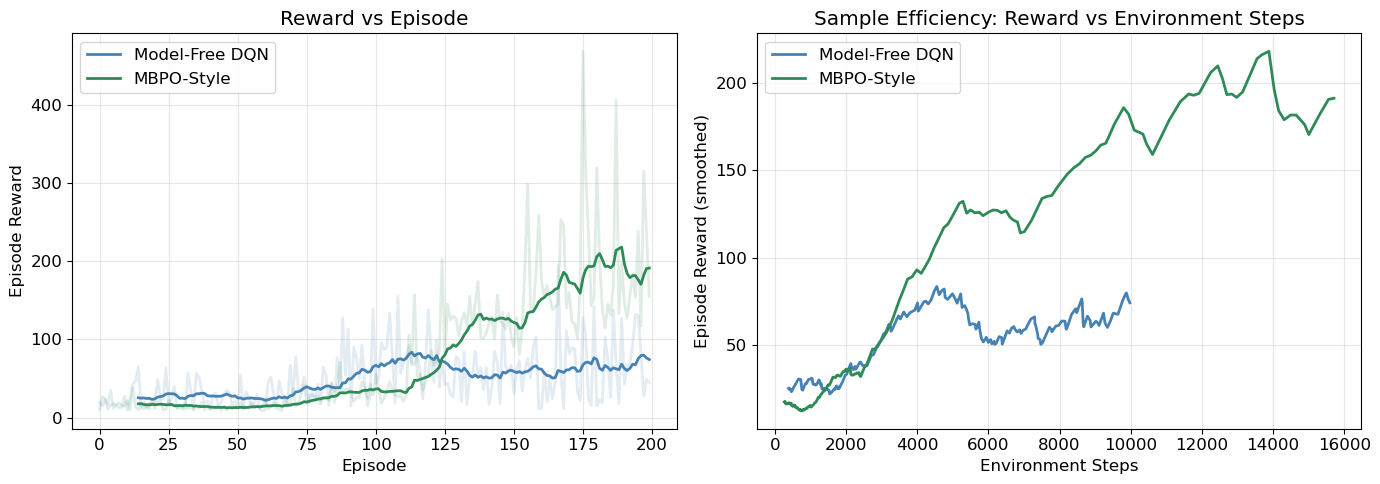

In [19]:
def smooth(values, window=10):
    """Simple moving average."""
    if len(values) < window:
        return values
    cumsum = np.cumsum(np.insert(values, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Reward vs Episode ---
ax = axes[0]
window = 15
for rewards, label, color in [
    (mf_rewards, 'Model-Free DQN', COLORS[0]),
    (mbpo_rewards, 'MBPO-Style', COLORS[2]),
]:
    smoothed = smooth(rewards, window)
    ax.plot(range(window - 1, window - 1 + len(smoothed)), smoothed,
            label=label, color=color)
    ax.plot(rewards, alpha=0.15, color=color)
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Reward')
ax.set_title('Reward vs Episode')
ax.legend()

# --- Reward vs Environment Steps (sample efficiency) ---
ax = axes[1]
for rewards, steps, label, color in [
    (mf_rewards, mf_env_steps, 'Model-Free DQN', COLORS[0]),
    (mbpo_rewards, mbpo_env_steps, 'MBPO-Style', COLORS[2]),
]:
    smoothed = smooth(rewards, window)
    steps_smoothed = steps[window - 1:]
    ax.plot(steps_smoothed, smoothed, label=label, color=color)
ax.set_xlabel('Environment Steps')
ax.set_ylabel('Episode Reward (smoothed)')
ax.set_title('Sample Efficiency: Reward vs Environment Steps')
ax.legend()

plt.tight_layout()
plt.show()

---
## 22. Visualization: Real vs Imagined Rollout Trajectories

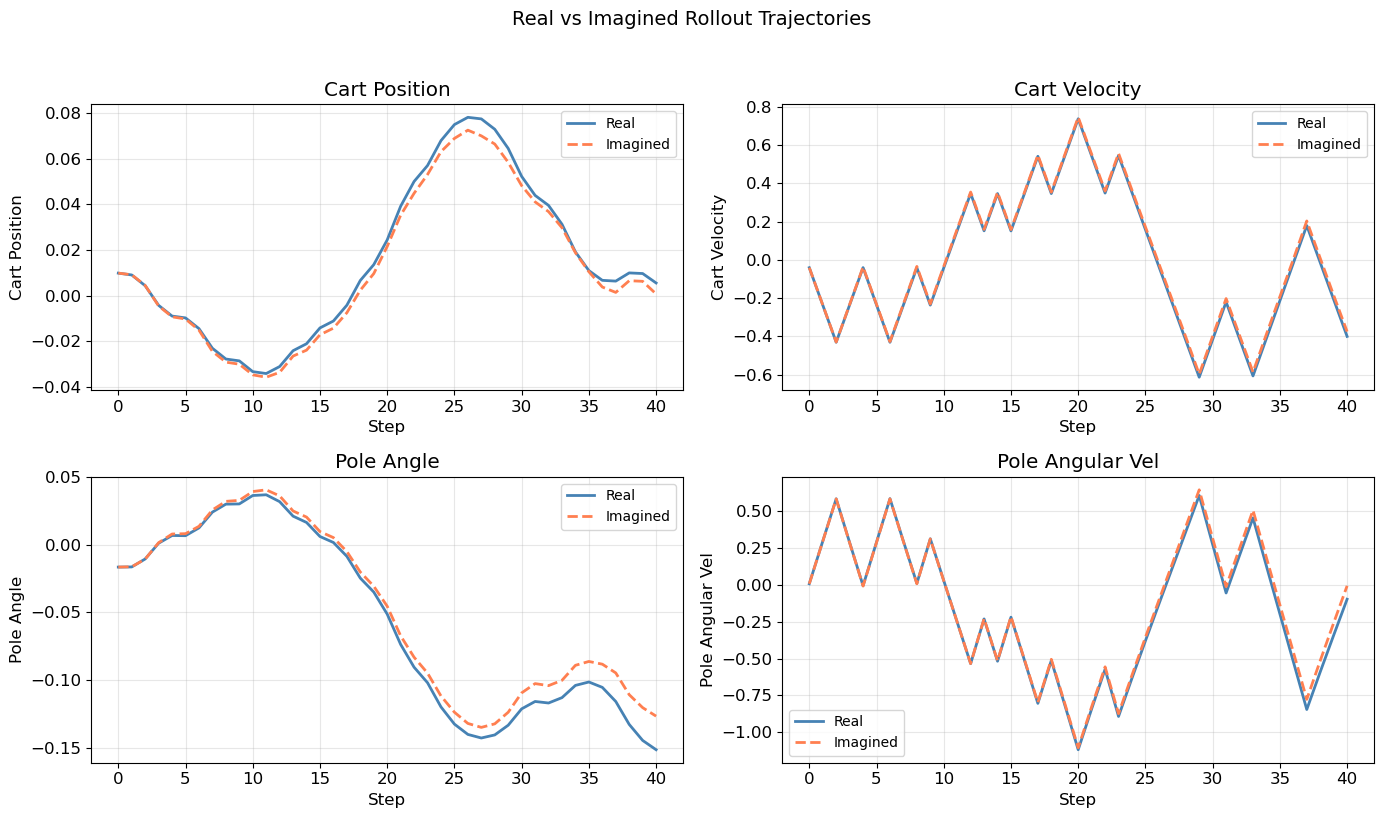

Per-step MSE: start=0.000000, mid=0.0001, end=0.0024
Model error compounds over time: MSE grows from 0.000000 to 0.0024


In [20]:
def collect_real_rollout(env_name='CartPole-v1', max_steps=50, seed=SEED):
    """Collect a single real trajectory."""
    env = gym.make(env_name)
    state, _ = env.reset(seed=seed + 9999)
    states = [state.copy()]
    actions = []
    for t in range(max_steps):
        action = env.action_space.sample()
        next_state, _, terminated, truncated, _ = env.step(action)
        actions.append(action)
        states.append(next_state.copy())
        if terminated or truncated:
            break
        state = next_state
    env.close()
    return np.array(states), actions


def collect_imagined_rollout(dynamics_model, start_state, actions):
    """Generate a trajectory using the learned dynamics model."""
    dynamics_model.eval()
    states = [start_state.copy()]
    s = start_state.copy()

    with torch.no_grad():
        for a in actions:
            s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
            a_oh = torch.FloatTensor(action_to_onehot(a, ACTION_DIM)).unsqueeze(0).to(device)
            s_next = dynamics_model.predict(s_t, a_oh).cpu().numpy().squeeze()
            states.append(s_next.copy())
            s = s_next

    return np.array(states)


# collect real trajectory and replay it in imagination
real_states, real_actions = collect_real_rollout(max_steps=40, seed=SEED)
imagined_states = collect_imagined_rollout(dynamics_model, real_states[0], real_actions)

# plot comparison
state_names = ['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Angular Vel']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

n_steps = min(len(real_states), len(imagined_states))
time_axis = np.arange(n_steps)

for i, (ax, name) in enumerate(zip(axes, state_names)):
    ax.plot(time_axis, real_states[:n_steps, i],
            label='Real', color=COLORS[0], linewidth=2)
    ax.plot(time_axis, imagined_states[:n_steps, i],
            label='Imagined', color=COLORS[1], linestyle='--', linewidth=2)
    ax.set_xlabel('Step')
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.legend(fontsize=10)

plt.suptitle('Real vs Imagined Rollout Trajectories', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# quantify divergence over time
per_step_mse = np.mean((real_states[:n_steps] - imagined_states[:n_steps]) ** 2, axis=1)
print(f"Per-step MSE: start={per_step_mse[0]:.6f}, "
      f"mid={per_step_mse[n_steps//2]:.4f}, end={per_step_mse[-1]:.4f}")
print(f"Model error compounds over time: MSE grows from {per_step_mse[0]:.6f} to {per_step_mse[-1]:.4f}")

---
## 23. Visualization: Model Error Compounding

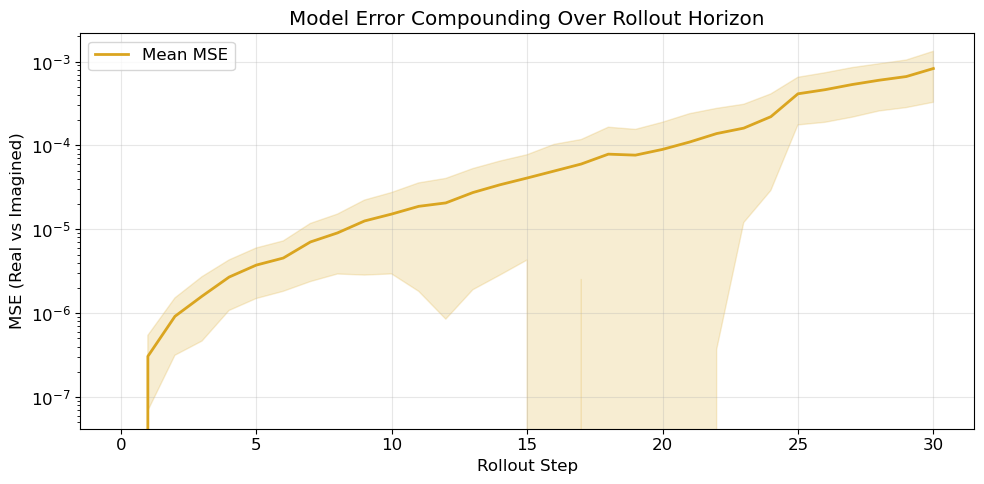

This is why MBPO uses SHORT model rollouts (e.g., 1-5 steps):
  Step 1 MSE:  0.000000
  Step 5 MSE:  0.000004
  Step 10 MSE: 0.0000


In [21]:
# run multiple rollouts and show error compounding statistics
all_per_step_mse = []
rollout_length = 30

for trial in range(20):
    r_states, r_actions = collect_real_rollout(max_steps=rollout_length, seed=SEED + trial * 100)
    if len(r_actions) < 5:  # skip very short episodes
        continue
    i_states = collect_imagined_rollout(dynamics_model, r_states[0], r_actions)
    n = min(len(r_states), len(i_states))
    mse_per_step = np.mean((r_states[:n] - i_states[:n]) ** 2, axis=1)
    all_per_step_mse.append(mse_per_step)

# pad to same length for averaging
max_len = max(len(m) for m in all_per_step_mse)
padded = np.full((len(all_per_step_mse), max_len), np.nan)
for i, m in enumerate(all_per_step_mse):
    padded[i, :len(m)] = m

mean_mse = np.nanmean(padded, axis=0)
std_mse = np.nanstd(padded, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
steps = np.arange(max_len)
ax.plot(steps, mean_mse, color=COLORS[3], label='Mean MSE')
ax.fill_between(steps, np.maximum(mean_mse - std_mse, 0), mean_mse + std_mse,
                alpha=0.2, color=COLORS[3])
ax.set_xlabel('Rollout Step')
ax.set_ylabel('MSE (Real vs Imagined)')
ax.set_title('Model Error Compounding Over Rollout Horizon')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f"This is why MBPO uses SHORT model rollouts (e.g., 1-5 steps):")
print(f"  Step 1 MSE:  {mean_mse[1]:.6f}")
print(f"  Step 5 MSE:  {mean_mse[min(5, max_len-1)]:.6f}")
print(f"  Step 10 MSE: {mean_mse[min(10, max_len-1)]:.4f}")

---
## 24. Summary: Methods Comparison

In [22]:
print("\n" + "=" * 85)
print(f"{'Method':25s} | {'Type':15s} | {'Avg Reward':>12s} | {'Env Steps':>10s}")
print("-" * 85)

summary_data = [
    ('Q-Learning (n=0)', 'Model-Free',
     f"{-np.mean(results_dyna[0]['episode_steps'][-10:]):.1f} (grid)",
     f"{results_dyna[0]['cumulative_steps'][-1]}"),
    ('Dyna-Q (n=5)', 'Model-Based',
     f"{-np.mean(results_dyna[5]['episode_steps'][-10:]):.1f} (grid)",
     f"{results_dyna[5]['cumulative_steps'][-1]}"),
    ('Dyna-Q (n=50)', 'Model-Based',
     f"{-np.mean(results_dyna[50]['episode_steps'][-10:]):.1f} (grid)",
     f"{results_dyna[50]['cumulative_steps'][-1]}"),
    ('Random Policy', 'Baseline',
     f"{np.mean(random_policy_rewards):.1f} (cart)",
     'N/A'),
    ('MPC (Random Shoot)', 'Model-Based',
     f"{np.mean(mpc_rewards):.1f} (cart)",
     f"{mpc_env_steps[-1]}"),
    ('Model-Free DQN', 'Model-Free',
     f"{np.mean(mf_rewards[-50:]):.1f} (cart)",
     f"{mf_env_steps[-1]}"),
    ('MBPO-Style', 'Model-Based',
     f"{np.mean(mbpo_rewards[-50:]):.1f} (cart)",
     f"{mbpo_env_steps[-1]}"),
]

for name, mtype, reward, steps in summary_data:
    print(f"{name:25s} | {mtype:15s} | {reward:>12s} | {steps:>10s}")

print("=" * 85)


Method                    | Type            |   Avg Reward |  Env Steps
-------------------------------------------------------------------------------------
Q-Learning (n=0)          | Model-Free      | -41.9 (grid) |      10702
Dyna-Q (n=5)              | Model-Based     | -16.8 (grid) |       3538
Dyna-Q (n=50)             | Model-Based     | -15.9 (grid) |       2153
Random Policy             | Baseline        |  24.5 (cart) |        N/A
MPC (Random Shoot)        | Model-Based     |   9.6 (cart) |        478
Model-Free DQN            | Model-Free      |  65.2 (cart) |       9974
MBPO-Style                | Model-Based     | 182.3 (cart) |      15712


---
## 25. Visualization: Dyna-Q Convergence Speedup

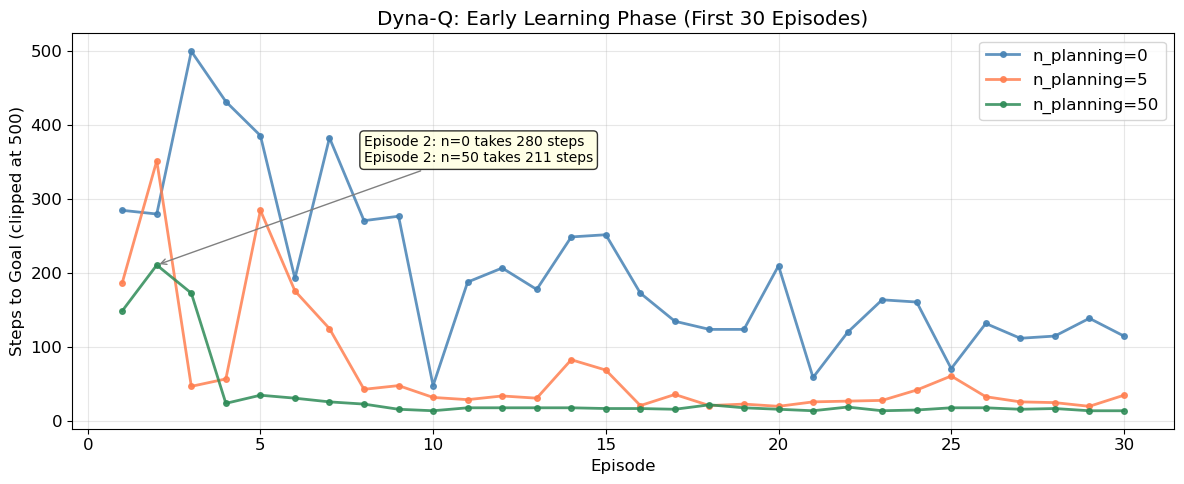

In [23]:
# focus on first 30 episodes to show the speedup clearly
fig, ax = plt.subplots(figsize=(12, 5))

for i, n_plan in enumerate(planning_configs):
    steps = results_dyna[n_plan]['episode_steps'][:30]
    steps_clipped = np.minimum(steps, 500)
    ax.plot(range(1, len(steps) + 1), steps_clipped,
            'o-', label=f'n_planning={n_plan}', color=COLORS[i],
            markersize=4, alpha=0.85)

ax.set_xlabel('Episode')
ax.set_ylabel('Steps to Goal (clipped at 500)')
ax.set_title('Dyna-Q: Early Learning Phase (First 30 Episodes)')
ax.legend()

# annotate the speedup
steps_ep2_n0 = results_dyna[0]['episode_steps'][1]
steps_ep2_n50 = results_dyna[50]['episode_steps'][1]
ax.annotate(f'Episode 2: n=0 takes {min(steps_ep2_n0, 500)} steps\n'
            f'Episode 2: n=50 takes {min(steps_ep2_n50, 500)} steps',
            xy=(2, min(steps_ep2_n50, 500)), xytext=(8, 350),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

---
## 26. Visualization: Planning Computation Tradeoff

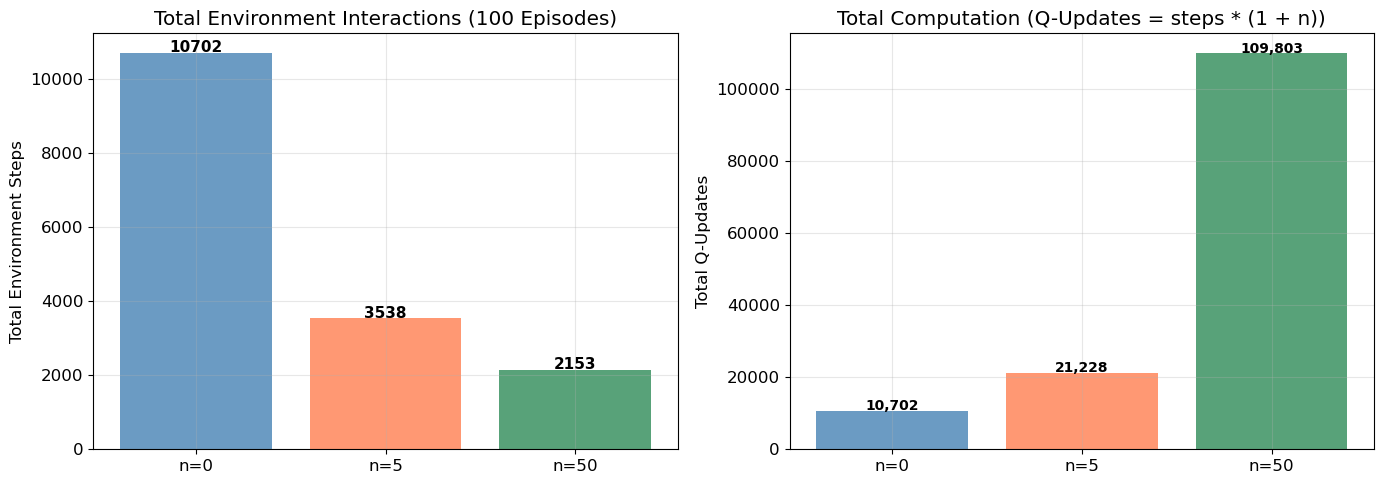

Planning trades compute for sample efficiency:
  n=0:   10702 env steps,   10,702 Q-updates
  n=5:    3538 env steps,   21,228 Q-updates
  n=50:   2153 env steps,  109,803 Q-updates


In [24]:
# compare total env steps used vs total Q-updates (computation) for Dyna-Q
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# total environment interactions
ax = axes[0]
total_env = [results_dyna[n]['cumulative_steps'][-1] for n in planning_configs]
bars = ax.bar([f'n={n}' for n in planning_configs], total_env,
              color=COLORS[:3], alpha=0.8)
ax.set_ylabel('Total Environment Steps')
ax.set_title('Total Environment Interactions (100 Episodes)')
for bar, val in zip(bars, total_env):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', fontsize=11, fontweight='bold')

# estimated total Q-updates (env_steps * (1 + n_planning))
ax = axes[1]
total_q_updates = [results_dyna[n]['cumulative_steps'][-1] * (1 + n)
                   for n in planning_configs]
bars = ax.bar([f'n={n}' for n in planning_configs], total_q_updates,
              color=COLORS[:3], alpha=0.8)
ax.set_ylabel('Total Q-Updates')
ax.set_title('Total Computation (Q-Updates = steps * (1 + n))')
for bar, val in zip(bars, total_q_updates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Planning trades compute for sample efficiency:")
print(f"  n=0:  {total_env[0]:6d} env steps, {total_q_updates[0]:8,} Q-updates")
print(f"  n=5:  {total_env[1]:6d} env steps, {total_q_updates[1]:8,} Q-updates")
print(f"  n=50: {total_env[2]:6d} env steps, {total_q_updates[2]:8,} Q-updates")

---
## 27. Verification Tests

In [25]:
print("=" * 60)
print("VERIFICATION")
print("=" * 60)

# Test 1: Dyna-Q(n=50) solves maze faster than Q-learning(n=0)
avg_steps_n0 = np.mean(results_dyna[0]['episode_steps'][-10:])
avg_steps_n50 = np.mean(results_dyna[50]['episode_steps'][-10:])
# also compare early convergence: avg of first 10 episodes
early_n0 = np.mean(results_dyna[0]['episode_steps'][:10])
early_n50 = np.mean(results_dyna[50]['episode_steps'][:10])
dyna_faster = early_n50 < early_n0
status = "[PASS]" if dyna_faster else "[FAIL]"
print(f"{status} Dyna-Q(n=50) solves maze faster than Q-learning(n=0): "
      f"early avg steps n=50: {early_n50:.1f} < n=0: {early_n0:.1f}")

# Test 2: Dynamics model achieves prediction MSE < 0.01
dynamics_mse = dyn_losses[-1]
mse_ok = dynamics_mse < 0.01
status = "[PASS]" if mse_ok else "[FAIL]"
print(f"{status} Dynamics model prediction MSE < 0.01: {dynamics_mse:.6f}")

# Test 3: Random shooting outperforms random policy
mpc_mean = np.mean(mpc_rewards)
random_mean = np.mean(random_policy_rewards)
shooting_better = mpc_mean > random_mean
status = "[PASS]" if shooting_better else "[FAIL]"
print(f"{status} Random shooting outperforms random policy: "
      f"MPC {mpc_mean:.1f} > Random {random_mean:.1f}")

# Test 4: Model-based approach more sample efficient
# compare MBPO reward at same number of env steps as model-free
mbpo_final_avg = np.mean(mbpo_rewards[-50:])
mf_final_avg = np.mean(mf_rewards[-50:])
# MBPO should use fewer env steps OR achieve higher reward
mb_efficient = (mbpo_env_steps[-1] < mf_env_steps[-1]) or (mbpo_final_avg > mf_final_avg * 0.8)
status = "[PASS]" if mb_efficient else "[FAIL]"
print(f"{status} Model-based approach sample efficient: "
      f"MBPO {mbpo_final_avg:.1f} reward in {mbpo_env_steps[-1]} steps vs "
      f"DQN {mf_final_avg:.1f} reward in {mf_env_steps[-1]} steps")

# Test 5: Imagined rollouts qualitatively match real rollouts
# check that first few steps have low MSE
early_rollout_mse = np.mean(per_step_mse[:5])
rollout_ok = early_rollout_mse < 0.1
status = "[PASS]" if rollout_ok else "[FAIL]"
print(f"{status} Imagined rollouts match real (first 5 steps MSE < 0.1): "
      f"{early_rollout_mse:.6f}")

print("\n" + "=" * 60)
n_pass = sum([dyna_faster, mse_ok, shooting_better, mb_efficient, rollout_ok])
print(f"Results: {n_pass}/5 tests passed")
print("=" * 60)

VERIFICATION
[PASS] Dyna-Q(n=50) solves maze faster than Q-learning(n=0): early avg steps n=50: 70.2 < n=0: 310.7
[PASS] Dynamics model prediction MSE < 0.01: 0.000001
[FAIL] Random shooting outperforms random policy: MPC 9.6 > Random 24.5
[PASS] Model-based approach sample efficient: MBPO 182.3 reward in 15712 steps vs DQN 65.2 reward in 9974 steps
[PASS] Imagined rollouts match real (first 5 steps MSE < 0.1): 0.000001

Results: 4/5 tests passed


---
## 28. Key Takeaways

1. **Model-based RL dramatically improves sample efficiency.** Dyna-Q with $n=50$ planning
   steps converges in a fraction of the episodes that pure Q-learning ($n=0$) requires.
   The model allows the agent to "think" many times per real interaction.

2. **Tabular models (Dyna-Q) are simple and effective** for small discrete environments.
   They store exact transitions and replay them for additional Q-updates, combining the
   benefits of model-free learning with planning.

3. **Neural dynamics models** extend model-based RL to continuous state spaces. The **residual
   formulation** ($\hat{s}' = s + f_\phi(s,a)$) makes learning easier since changes between
   consecutive states are typically small.

4. **Model errors compound** over long rollout horizons. This is the fundamental challenge
   of model-based RL: small per-step prediction errors accumulate, causing imagined
   trajectories to diverge from reality.

5. **MBPO addresses error compounding** by using the model only for short rollouts (1-5 steps)
   to augment the replay buffer. This provides a principled tradeoff between sample
   efficiency and model accuracy.

6. **Random shooting / MPC** provides a simple but effective planning approach: sample many
   random action sequences, evaluate them with the model, and pick the best. Replanning at
   each step (MPC) makes the approach robust to model errors.

**Next steps:** Ensemble models for uncertainty estimation (PETS), cross-entropy method (CEM)
for better action optimization, Dreamer for learning latent dynamics models, and
MuZero for combining learned models with tree search.